In [1]:
try:
    from pytabkit import TabM_D_Classifier
    from skrub import TableVectorizer
except:
    %pip install -q -U pytabkit
    %pip install -q -U skrub

    from pytabkit import TabM_D_Classifier
    from skrub import TableVectorizer

try:
    import xgboost as xgb
except:
    %pip install -q xgboost
    import xgboost as xgb

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 364.0/364.0 kB 8.2 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 519.2/519.2 kB 10.8 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.


In [2]:
## -- Device-Agnostic for GPU --
import torch
print(f"ℹ️ Running on Cuda: {torch.cuda.is_available()}")

# if torch.cuda.is_available():
#     # get_ipython().run_line_magic('load_ext', 'cudf.pandas')
#     # get_ipython().run_line_magic('load_ext', 'cuml.accel')
#     from cuml.preprocessing import TargetEncoder as cuTE
# else:
#     pass

ℹ️ Running on Cuda: True


In [3]:
## -- System dependencies --
import sys, os, gc

## -- Data Manipulation --
import numpy as np, pandas as pd, random

## -- Visualization --
from IPython.display import display, Image
import matplotlib.pyplot as plt
import seaborn as sns

## -- Functional Tools --
from time import time, sleep
from tqdm.notebook import tqdm
import itertools

## -- Machine Learning --
import tensorflow as tf

import sklearn
from sklearn.model_selection import KFold, StratifiedKFold, train_test_split
from sklearn.metrics import roc_auc_score, ConfusionMatrixDisplay, RocCurveDisplay
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.calibration import CalibrationDisplay

import warnings

print('📚 Libraries imported')

2026-03-28 20:34:41.559172: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1774730081.729198      24 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1774730081.780908      24 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1774730082.229420      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1774730082.229461      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1774730082.229464      24 computation_placer.cc:177] computation placer alr

📚 Libraries imported


In [4]:
## -- Global Settings --
# sklearn.set_config(transform_output="pandas")
warnings.simplefilter('ignore')
warnings.filterwarnings('ignore')

# pd.options.mode.copy_on_write = True
pd.set_option('display.max_columns', 1000)
sns.set_style("whitegrid")
# plt.style.use("ggplot")

PALETTE = ['#3A86FF', '#F94144', '#FFBE0B', '#73D2DE', '#FBB13C']
sns.set_palette(PALETTE)

cmap = sns.diverging_palette(0, 230, 90, 60, as_cmap=True)

## -- Set Global Seed --
SEED = 42
tf.keras.utils.set_random_seed(SEED)

GREEN  = '\033[32m'
YELLOW = '\033[33m'
RESET  = '\033[0m'
RED    = '\033[31m'

print(f"CLASSIC {GREEN} GREEN {RESET} {YELLOW} YELLOW {RESET} {RED} RED {RESET}")

CLASSIC  GREEN   YELLOW   RED 


In [5]:
# # -- Load Colab Data --
# from google.colab import drive
# drive.mount('/content/drive')

# PATH = '/content/drive/MyDrive/--colab--notebooks--/Ps6e1 | Student Test Score/student_test_dataset/'
# submit = pd.read_csv(PATH+'sample_submission.csv')
# train = pd.read_csv(PATH+'train.csv').drop('id', axis=1)
# test = pd.read_csv(PATH+'test.csv').drop('id', axis=1)

# TARGET = train.columns[-1]
# NUMS = test.select_dtypes(include='number').columns.tolist()
# CATS = test.select_dtypes(exclude='number').columns.tolist()
# BASE = NUMS + CATS

# orig = pd.read_csv(PATH+'Exam_Score_Prediction.csv').drop('student_id', axis=1)

# for (name, df) in dict(Train=train, Test=test, Original=orig).items():
#     print(f"{name} shape: {df.shape}")

# print(f"\nTotal Numerical: {len(NUMS)}")
# print(f"Total Categorical: {len(CATS)}")
# print(f"Total base features: {len(BASE)}")

In [6]:
## -- Load Data --
PATH = '/kaggle/input/competitions/playground-series-s6e3/'
submit = pd.read_csv(PATH+'sample_submission.csv')
train = pd.read_csv(PATH+"train.csv").drop(['id'], axis=1)
test = pd.read_csv(PATH+"test.csv").drop(['id'], axis=1)

ORIG_PATH = '/kaggle/input/datasets/sylvesterdalmeida/telco-customer-churn/'
orig = pd.read_csv(ORIG_PATH+'WA_Fn-UseC_-Telco-Customer-Churn.csv').drop(['customerID'], axis=1)

TARGET = train.columns[-1]
NUMS   = ['tenure', 'MonthlyCharges', 'TotalCharges']
CATS   = [c for c in train.columns if c not in NUMS+[TARGET, 'id']] 
BASE   = NUMS + CATS

for df in [train, orig]:
    df[TARGET] = df[TARGET].map({'Yes':1, 'No': 0})

for (name, df) in dict(Train=train, Test=test, Original=orig).items():
    print(f"{name} shape: {df.shape}")

print(f"\nTotal Numerical: {len(NUMS)}")
print(f"Total Categorical: {len(CATS)}")
print(f"Total base features: {len(BASE)}")

Train shape: (594194, 20)
Test shape: (254655, 19)
Original shape: (7043, 20)

Total Numerical: 3
Total Categorical: 16
Total base features: 19


In [7]:
display(train.head())
train.info()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Male,0,Yes,Yes,29,Yes,No,DSL,Yes,No,Yes,Yes,No,No,One year,Yes,Mailed check,60.10,1653.85,0
1,Male,0,Yes,Yes,58,Yes,No,DSL,Yes,Yes,No,Yes,Yes,No,Two year,No,Credit card (automatic),69.50,3778.20,0
2,Male,0,Yes,No,58,Yes,Yes,Fiber optic,No,Yes,No,No,Yes,Yes,Month-to-month,Yes,Electronic check,100.40,5841.35,0
3,Female,0,No,No,1,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,69.70,70.70,1
4,Female,0,No,No,1,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.45,70.45,1


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 594194 entries, 0 to 594193
Data columns (total 20 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   gender            594194 non-null  object 
 1   SeniorCitizen     594194 non-null  int64  
 2   Partner           594194 non-null  object 
 3   Dependents        594194 non-null  object 
 4   tenure            594194 non-null  int64  
 5   PhoneService      594194 non-null  object 
 6   MultipleLines     594194 non-null  object 
 7   InternetService   594194 non-null  object 
 8   OnlineSecurity    594194 non-null  object 
 9   OnlineBackup      594194 non-null  object 
 10  DeviceProtection  594194 non-null  object 
 11  TechSupport       594194 non-null  object 
 12  StreamingTV       594194 non-null  object 
 13  StreamingMovies   594194 non-null  object 
 14  Contract          594194 non-null  object 
 15  PaperlessBilling  594194 non-null  object 
 16  PaymentMethod     59

In [8]:
train[NUMS].describe()

,tenure,MonthlyCharges,TotalCharges
count,594194.000000,594194.000000,594194.000000
mean,36.577258,65.866223,2494.377057
std,25.061922,31.067444,2353.916710
min,1.000000,18.250000,18.800000
25%,12.000000,29.900000,639.650000
50%,35.000000,74.100000,1433.650000
75%,62.000000,90.800000,4263.800000
max,72.000000,118.750000,8684.800000


In [9]:
## -- FIX ORIGINAL COLUMN --
orig['TotalCharges'] = orig['TotalCharges'].replace(' ', np.nan).astype(float)
orig['TotalCharges'] = orig['TotalCharges'].fillna(orig['TotalCharges'].median())

display(orig.head())
orig.info()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,0
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   object 
 1   SeniorCitizen     7043 non-null   int64  
 2   Partner           7043 non-null   object 
 3   Dependents        7043 non-null   object 
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   object 
 6   MultipleLines     7043 non-null   object 
 7   InternetService   7043 non-null   object 
 8   OnlineSecurity    7043 non-null   object 
 9   OnlineBackup      7043 non-null   object 
 10  DeviceProtection  7043 non-null   object 
 11  TechSupport       7043 non-null   object 
 12  StreamingTV       7043 non-null   object 
 13  StreamingMovies   7043 non-null   object 
 14  Contract          7043 non-null   object 
 15  PaperlessBilling  7043 non-null   object 
 16  PaymentMethod     7043 non-null   object 


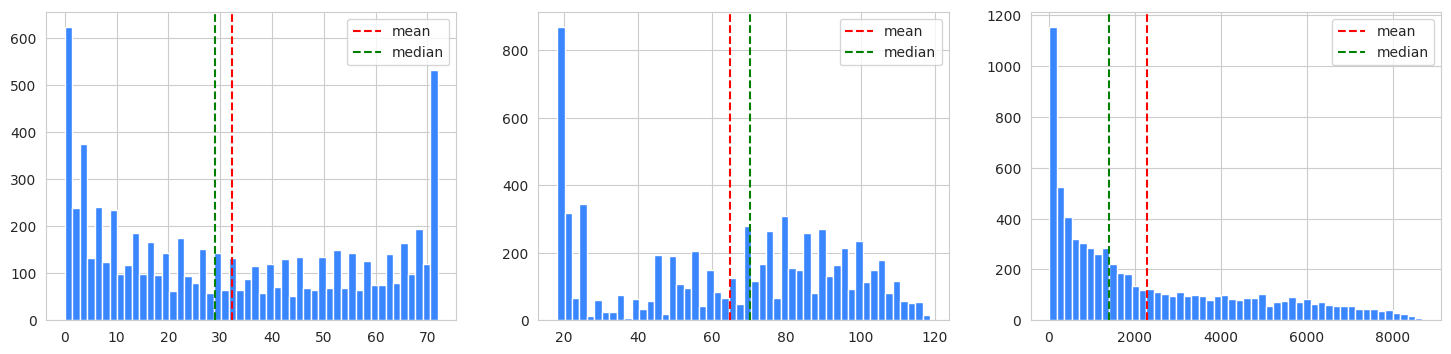

In [10]:
plt.figure(figsize=(18, 4))

for i, col in enumerate(NUMS):
    plt.subplot(1, 3, i+1)
    ax = plt.hist(orig[col], bins=50)
    plt.axvline(x=orig[col].mean(), color='r', linestyle='--', label='mean')
    plt.axvline(x=orig[col].median(), color='g', linestyle='--', label='median')
    plt.legend()
    
plt.show()

In [11]:
## -- Unique value counts for each dataset --
TRAIN_UNIQUE = {}
ORIGINAL_UNIQUE = {}
TEST_UNIQUE = {}

for col in BASE:
    TRAIN_UNIQUE[col] = train[col].nunique()
    ORIGINAL_UNIQUE[col] = orig[col].nunique()
    TEST_UNIQUE[col] = test[col].nunique()

unique_counts_df = pd.concat(
        [pd.DataFrame(TRAIN_UNIQUE, index=['Train']),
         pd.DataFrame(ORIGINAL_UNIQUE, index=['Original']),
         pd.DataFrame(TEST_UNIQUE, index=['Test'])],
    )

unique_counts_df.style.background_gradient(cmap='bone')

,tenure,MonthlyCharges,TotalCharges,gender,SeniorCitizen,Partner,Dependents,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod
Train,72,1921,31910,2,2,2,2,2,3,3,3,3,3,3,3,3,3,2,4
Original,73,1585,6531,2,2,2,2,2,3,3,3,3,3,3,3,3,3,2,4
Test,72,1875,24995,2,2,2,2,2,3,3,3,3,3,3,3,3,3,2,4


In [12]:
# !pip install -qq -U optbinning

# from optbinning import OptimalBinning

In [13]:
# def _opt_binning(x_train, y, bin_features, dtype=None, x_val=None, x_test=None):
#     print(f'OptimalBinning: ', end='')
#     for col in bin_features:
#         print(f'{col}... ', end='')
#         if dtype == 'num':
#             optb = OptimalBinning(name='binary_mean', dtype='numerical', solver='cp')
#         else:
#             optb = OptimalBinning(name='binary_mean', dtype='categorical', solver='mip')
        
#         optb.fit(x_train[col].to_numpy(), y)
#         # display(optb.information(print_level=0))
        
#         new_col = f'{col}_OptBin'
#         x_train[new_col] = optb.transform(x_train[col].to_numpy(), metric='indices')
#         if x_val is not None:
#             x_val[new_col] = optb.transform(x_val[col].to_numpy(), metric='indices')
#         if x_test is not None:
#             x_test[new_col] = optb.transform(x_test[col].to_numpy(), metric='indices')
#     print(f'Done!')
#     return x_train, x_val, x_test

In [14]:
# train2, orig2, _ = _opt_binning(
#     x_train=train,
#     y=train[TARGET],
#     bin_features=NUMS,
#     dtype='num',
#     x_val=orig,
#     x_test=None,
# )

# train2, orig2, _ = _opt_binning(
#     x_train=train2,
#     y=train2[TARGET],
#     bin_features=CATS,
#     # dtype='numerical',
#     x_val=orig2,
#     x_test=None,
# )

# train2.head()

In [15]:
# optb.status, optb.splits

In [16]:
# binning_table = optb.binning_table
# print(type(binning_table))

# binning_table.build()

In [17]:
# for i, m in enumerate(['woe', 'event_rate']):
#     binning_table.plot(metric=m)

# plt.show()

In [18]:
# x_transform_woe = optb.transform(train['TotalCharges'].to_numpy(), metric="woe")
# pd.Series(x_transform_woe).value_counts()

In [19]:
# x_transform_event_rate = optb.transform(train['TotalCharges'].to_numpy(), metric="event_rate")
# pd.Series(x_transform_event_rate).value_counts()

In [20]:
# x_transform_indices = optb.transform(train['TotalCharges'].to_numpy(), metric="indices")
# pd.Series(x_transform_indices).value_counts()

## FEATURE ENGINEERING

In [21]:
## -- EXTRACTIONS & BINNING --
ROUNDS = []
DIGITS = []
E_BINS = []
Q_BINS = []

In [22]:
for col in ['TotalCharges']:
    print(f"\nEXTRACTING ROUNDS... ", end='')
    for r in [-3, -2, -1, 0, 1]:
        r_n = f"{col}_round_{r}"
        print(r_n+', ', end='')
        train[r_n] = train[col].round(r).astype('int32')
        test[r_n]  = test[col].round(r).astype('int32')
        orig[r_n]  = orig[col].round(r).astype('int32')
        ## -- Drop irrelevant features --
        if train[r_n].nunique() <= 2:
            train = train.drop([r_n], axis=1)
            test  = test.drop([r_n], axis=1)
            orig  = orig.drop([r_n], axis=1)
        elif train[r_n].nunique() == train[col].nunique():
            train = train.drop([r_n], axis=1)
            test  = test.drop([r_n], axis=1)
            orig  = orig.drop([r_n], axis=1)
        else:
            ROUNDS.append(r_n)

    print(f"\nEXTRACTING DIGITS... ", end='')
    for d in [-3, -2, -1, 0, 1, 2]:
        d_n = f'{col}_digit_{d}'
        print(d_n+', ', end='')
        train[d_n] = ((train[col] * 10**d) % 10).fillna(-1).astype('int32')
        test[d_n]  = ((test[col]  * 10**d) % 10).fillna(-1).astype('int32')
        orig[d_n]  = ((orig[col]  * 10**d) % 10).fillna(-1).astype('int32')
        ## -- Drop constant features --
        if train[d_n].nunique() < 2:
            train = train.drop([d_n], axis=1)
            test  = test.drop([d_n], axis=1)
            orig  = orig.drop([d_n], axis=1)
        else:
            DIGITS.append(d_n)

    print(f"\nCREATING E_BINS... ", end='')
    for b in [500, 4000]: # 100, 500, 1000
        b_n = f'{col}_bin_{b}'
        print(b_n+', ', end='')
        train[b_n], edges = pd.cut(train[col], bins=b, retbins=True, include_lowest=True, labels=False)
        test[b_n] = pd.cut(test[col], bins=edges, include_lowest=True, labels=False)
        orig[b_n] = pd.cut(orig[col], bins=edges, include_lowest=True, labels=False)
        E_BINS.append(b_n)

    print(f"\nQUANTILE BINNING... ", end='')
    for q in [500, 4000]: # 100, 500, 1000
        q_n = f'{col}_Qbin_{q}'
        print(q_n+', ', end='')
        train[q_n], edges = pd.qcut(train[col], q=q, retbins=True, duplicates='drop', labels=False)
        test[q_n] = pd.cut(test[col], bins=edges, include_lowest=True, labels=False)
        orig[q_n] = pd.cut(orig[col], bins=edges, include_lowest=True, labels=False)
        Q_BINS.append(q_n)
        
print()
print('-'*50)
print(f'✅ TOTAL ROUND FEATURES: {len(ROUNDS)}')
print(f"✅ TOTAL DIGITS EXTRACTED: {len(DIGITS)}")
print(f"✅ TOTAL EQUAL E_BINS: {len(E_BINS)}")
print(f"✅ TOTAL QUANTILE E_BINS: {len(Q_BINS)}")


EXTRACTING ROUNDS... TotalCharges_round_-3, TotalCharges_round_-2, TotalCharges_round_-1, TotalCharges_round_0, TotalCharges_round_1, 
EXTRACTING DIGITS... TotalCharges_digit_-3, TotalCharges_digit_-2, TotalCharges_digit_-1, TotalCharges_digit_0, TotalCharges_digit_1, TotalCharges_digit_2, 
CREATING E_BINS... TotalCharges_bin_500, TotalCharges_bin_4000, 
QUANTILE BINNING... TotalCharges_Qbin_500, TotalCharges_Qbin_4000, 
--------------------------------------------------
✅ TOTAL ROUND FEATURES: 5
✅ TOTAL DIGITS EXTRACTED: 6
✅ TOTAL EQUAL E_BINS: 2
✅ TOTAL QUANTILE E_BINS: 2


In [23]:
for col in ['MonthlyCharges']:
    print(f"\nROUNDING FEATURES... ", end='')
    for r in [-2, -1, 0]:
        r_n = f"{col}_round_{r}"
        print(r_n+', ', end='')
        train[r_n] = train[col].round(r).astype('int32')
        test[r_n]  = test[col].round(r).astype('int32')
        orig[r_n]  = orig[col].round(r).astype('int32')
        ## -- Drop irrelevant features --
        if train[r_n].nunique() <= 2:
            train = train.drop([r_n], axis=1)
            test  = test.drop([r_n], axis=1)
            orig  = orig.drop([r_n], axis=1)
        elif train[r_n].nunique() == train[col].nunique():
            train = train.drop([r_n], axis=1)
            test  = test.drop([r_n], axis=1)
            orig  = orig.drop([r_n], axis=1)
        else:
            ROUNDS.append(r_n)
    
    print(f"\nEXTRACTING DIGITS... ", end='')
    for d in [-2, -1, 0, 1, 2]:
        d_n = f'{col}_digit_{d}'
        print(d_n+', ', end='')
        train[d_n] = ((train[col] * 10**d) % 10).fillna(-1).astype('int32')
        test[d_n]  = ((test[col]  * 10**d) % 10).fillna(-1).astype('int32')
        orig[d_n]  = ((orig[col]  * 10**d) % 10).fillna(-1).astype('int32')

        ## -- Drop constant features --
        if train[d_n].nunique() < 2:
            train = train.drop([d_n], axis=1)
            test  = test.drop([d_n], axis=1)
            orig  = orig.drop([d_n], axis=1)
        else:
            DIGITS.append(d_n)
            
    print(f"\nEQUAL BINNING... ", end='')
    for b in [100, 500]: # 50, 100, 400
        b_n = f'{col}_bin_{b}'
        print(b_n+', ', end='')
        # Fit on train data and transform both train and test
        train[b_n], edges = pd.cut(train[col], bins=b, retbins=True, include_lowest=True, labels=False)
        test[b_n] = pd.cut(test[col], bins=edges, include_lowest=True, labels=False)
        orig[b_n] = pd.cut(orig[col], bins=edges, include_lowest=True, labels=False)
        E_BINS.append(b_n)
        
    print(f"\nQUANTILE BINNING... ", end='')
    for q in [100, 500]: # 50, 100, 400
        q_n = f'{col}_Qbin_{q}'
        print(q_n+', ', end='')
        train[q_n], edges = pd.qcut(train[col], q=q, retbins=True, duplicates='drop', labels=False)
        test[q_n] = pd.cut(test[col], bins=edges, include_lowest=True, labels=False)
        orig[q_n] = pd.cut(orig[col], bins=edges, include_lowest=True, labels=False)
        Q_BINS.append(q_n)

print()
print('-'*50)
print(f"✅ TOTAL DIGITS: {len(DIGITS)}")
print(f'✅ TOTAL ROUNDs: {len(ROUNDS)}')
print(f"✅ TOTAL EQUAL BINS: {len(E_BINS)}")
print(f"✅ TOTAL QUANTILE BINS: {len(Q_BINS)}")


ROUNDING FEATURES... MonthlyCharges_round_-2, MonthlyCharges_round_-1, MonthlyCharges_round_0, 
EXTRACTING DIGITS... MonthlyCharges_digit_-2, MonthlyCharges_digit_-1, MonthlyCharges_digit_0, MonthlyCharges_digit_1, MonthlyCharges_digit_2, 
EQUAL BINNING... MonthlyCharges_bin_100, MonthlyCharges_bin_500, 
QUANTILE BINNING... MonthlyCharges_Qbin_100, MonthlyCharges_Qbin_500, 
--------------------------------------------------
✅ TOTAL DIGITS: 11
✅ TOTAL ROUNDs: 7
✅ TOTAL EQUAL BINS: 4
✅ TOTAL QUANTILE BINS: 4


In [24]:
for col in ['tenure']:
    print(f"\nEXTRACTING ROUNDS... ", end='')
    for r in [-1]:
        r_n = f"{col}_round_{r}"
        print(r_n+', ', end='')
        train[r_n] = train[col].round(r).astype('int32')
        test[r_n]  = test[col].round(r).astype('int32')
        orig[r_n]  = orig[col].round(r).astype('int32')
        ## -- Drop irrelevant features --
        if train[r_n].nunique() <= 2:
            train = train.drop([r_n], axis=1)
            test  = test.drop([r_n], axis=1)
            orig  = orig.drop([r_n], axis=1)
        elif train[r_n].nunique() == train[col].nunique():
            train = train.drop([r_n], axis=1)
            test  = test.drop([r_n], axis=1)
            orig  = orig.drop([r_n], axis=1)
        else:
            ROUNDS.append(r_n)

    print(f"\nEXTRACTING DIGITS... ", end='')
    for d in [-1, 0]:
        d_n = f'{col}_digit_{d}'
        print(d_n+', ', end='')
        train[d_n] = ((train[col] * 10**d) % 10).fillna(-1).astype('int32')
        test[d_n]  = ((test[col]  * 10**d) % 10).fillna(-1).astype('int32')
        orig[d_n]  = ((orig[col]  * 10**d) % 10).fillna(-1).astype('int32')
        ## -- Drop constant features --
        if train[d_n].nunique() < 2:
            train = train.drop([d_n], axis=1)
            test  = test.drop([d_n], axis=1)
            orig  = orig.drop([d_n], axis=1)
        else:
            DIGITS.append(d_n)

    # print(f"\nEQUAL BINNING... ", end='')
    # for b in [12]: # 10, 50
    #     b_n = f'{col}_bin_{b}'
    #     print(b_n+', ', end='')
    #     # Fit on train data and transform both train and test
    #     train[b_n], edges = pd.cut(train[col], bins=b, retbins=True, include_lowest=True, labels=False)
    #     test[b_n] = pd.cut(test[col], bins=edges, include_lowest=True, labels=False)
    #     orig[b_n] = pd.cut(orig[col], bins=edges, include_lowest=True, labels=False)
    #     E_BINS.append(b_n)

    # print(f"\nQUANTILE BINNING... ", end='')
    # for q in [12]: # 10, 50
    #     q_n = f'{col}_Qbin_{q}'
    #     print(q_n+', ', end='')
    #     train[q_n], edges = pd.qcut(train[col], q=q, retbins=True, duplicates='drop', labels=False)
    #     test[q_n] = pd.cut(test[col], bins=edges, include_lowest=True, labels=False)
    #     orig[q_n]  = pd.cut(orig[col], bins=edges, include_lowest=True, labels=False)
    #     Q_BINS.append(q_n)

print()
print('-'*50)
print(f'✅ TOTAL ROUND FEATURES: {len(ROUNDS):<10}')
print(f"✅ TOTAL DIGITS FEATURES: {len(DIGITS):<10}")
print(f"✅ TOTAL EQUAL BINS: {len(E_BINS):<10}")
print(f"✅ TOTAL QUANTILE BINS: {len(Q_BINS):<10}")


EXTRACTING ROUNDS... tenure_round_-1, 
EXTRACTING DIGITS... tenure_digit_-1, tenure_digit_0, 
--------------------------------------------------
✅ TOTAL ROUND FEATURES: 8         
✅ TOTAL DIGITS FEATURES: 13        
✅ TOTAL EQUAL BINS: 4         
✅ TOTAL QUANTILE BINS: 4         


In [25]:
ALL_ROUND_BINS = ROUNDS + E_BINS + Q_BINS

train[ALL_ROUND_BINS].nunique().sort_values()

tenure_round_-1               8
TotalCharges_round_-3        10
MonthlyCharges_round_-1      11
TotalCharges_round_-2        88
MonthlyCharges_Qbin_100     100
MonthlyCharges_bin_100      100
MonthlyCharges_round_0      102
MonthlyCharges_Qbin_500     433
MonthlyCharges_bin_500      489
TotalCharges_bin_500        493
TotalCharges_Qbin_500       500
TotalCharges_round_-1       846
TotalCharges_bin_4000      3207
TotalCharges_Qbin_4000     3591
TotalCharges_round_1       5298
TotalCharges_round_0       5785
dtype: int64

In [26]:
LOW_100_UNIQUE = []

for col in ALL_ROUND_BINS:
    if train[col].nunique() < 100:
        LOW_100_UNIQUE.append(col)

print(f"Cats with ~100 unique: {len(LOW_100_UNIQUE)}")
print()
TOP_100_UNIQUE = [c for c in ALL_ROUND_BINS if c not in LOW_100_UNIQUE]
print(f"Cats with +100 unique: {len(TOP_100_UNIQUE)}")

Cats with ~100 unique: 4

Cats with +100 unique: 12


In [27]:
## -- Arithmetic interaction --
for df in [train, test, orig]:
    df['_MonthlyCharges_/_TotalCharges'] = (df['MonthlyCharges'] / (df['TotalCharges'] + 1e-6)).astype('float32')
    df['_TotalCharges_/_tenure']  = (df['TotalCharges'] / (df['tenure'] + 1e-6)).astype('float32')
    df['_Monthly_to_avg_ratio'] = (df['MonthlyCharges'] / (df['_TotalCharges_/_tenure'] + 1e-6)).astype('float32')
    df['_TotalCharges_/_MonthlyCharges']  = (df['TotalCharges'] / (df['MonthlyCharges'] + 1e-6)).astype('float32')
    df['_tenure_sq'] = (df['tenure'] ** 2).astype("float32")

arithmetic = ['_MonthlyCharges_/_TotalCharges', '_TotalCharges_/_tenure',
              '_Monthly_to_avg_ratio', '_TotalCharges_/_MonthlyCharges', '_tenure_sq']

train[arithmetic].head()

,_MonthlyCharges_/_TotalCharges,_TotalCharges_/_tenure,_Monthly_to_avg_ratio,_TotalCharges_/_MonthlyCharges,_tenure_sq
0,0.036339,57.029308,1.053844,27.518303,841.0
1,0.018395,65.141380,1.066910,54.362591,3364.0
2,0.017188,100.712929,0.996893,58.180775,3364.0
3,0.985856,70.699928,0.985857,1.014347,1.0
4,1.000000,70.449928,1.000001,1.000000,1.0


In [28]:
# ## -- Cyclic encoding --
# for df in [train, test, orig]:
#     for p in [12, 30]:
#         df[f"MonthlyCharges_sin_{p}"] = np.sin(2 * np.pi * df['MonthlyCharges'] / p).astype('float32')
#         df[f"MonthlyCharges_cos_{p}"] = np.cos(2 * np.pi * df['MonthlyCharges'] / p).astype('float32')

In [29]:
# ## -- FREQUENCY ENCODING --
# NUMS_FREQ = []
# print(f"\nCREATING FREQUENCIES... ", end='')
# for col in NUMS:
#     freq = pd.concat([train[col], orig[col], test[col]]).value_counts(normalize=True)
#     n = f'{col}_FREQ'
#     print(n+', ', end='')
#     for df in [train, test, orig]:
#         df[n] = df[col].map(freq).fillna(0).astype('float32')
#     NUMS_FREQ.append(n)
    
# print()
# print(f"✅ TOTAL FREQUENCY FEEATURES: {len(NUMS_FREQ)}")

In [30]:
INTER = []
TOP_CATS = ['Contract', 'InternetService', 'PaymentMethod']

for c1, c2 in tqdm(list(itertools.combinations(TOP_CATS, 2)), desc='Pairwise'):
    n_col = f"Bi_{c1}-|-{c2}"
    train[n_col] = train[c1].astype(str) + '_' + train[c2].astype(str)
    test[n_col]  = test[c1].astype(str) + '_' + test[c2].astype(str)
    orig[n_col]  = orig[c1].astype(str) + '_' + orig[c2].astype(str)
    INTER.append(n_col)

for c1, c2, c3 in tqdm(list(itertools.combinations(TOP_CATS, 3)), desc='Triplewise'):
    n_col = f"Tri_{c1}-|-{c2}-|-{c3}"
    train[n_col] = train[c1].astype(str) + '_' + train[c2].astype(str) + '_' + train[c3].astype(str)
    test[n_col] = test[c1].astype(str) + '_' + test[c2].astype(str) + '_' + test[c3].astype(str)
    INTER.append(n_col)

# for c1, c2 in tqdm(list(itertools.product(TOP_PREDICTORS, OTHER_PREDICTORS)), desc='One-To-Many Pairwise'):
#     new_col = f"{c1}-|-{c2}"
#     train[new_col] = train[c1].astype(str) + '_' + train[c2].astype(str)
#     test[new_col] = test[c1].astype(str) + '_' + test[c2].astype(str)
#     orig[new_col] = orig[c1].astype(str) + '_' + orig[c2].astype(str)
#     INTER.append(new_col)

print(f"TOTAL INTERACTION FEATURES: {len(INTER)}")
train[INTER].nunique().sort_values()

Pairwise:   0%|          | 0/3 [00:00<?, ?it/s]

Triplewise:   0%|          | 0/1 [00:00<?, ?it/s]

TOTAL INTERACTION FEATURES: 4


Bi_Contract-|-InternetService                      9
Bi_Contract-|-PaymentMethod                       12
Bi_InternetService-|-PaymentMethod                12
Tri_Contract-|-InternetService-|-PaymentMethod    36
dtype: int64

In [31]:
from sklearn.base import BaseEstimator, TransformerMixin ## ===== Target/Category Mean ENCODERS =====

class TargetEncoder(BaseEstimator, TransformerMixin):
    """
    Target Encoder that supports multiple aggregation functions,
    internal cross-validation for leakage prevention, and smoothing.

    Parameters
    ----------
    cols_to_encode : list of str
        List of column names to be target encoded.

    aggs : list of str, default=['mean']
        List of aggregation functions to apply. Any function accepted by
        pandas' `.agg()` method is supported, such as:
        'mean', 'std', 'var', 'min', 'max', 'skew', 'nunique', 
        'count', 'sum', 'median'.
        Smoothing is applied only to the 'mean' aggregation.

    cv : int, default=5
        Number of folds for cross-validation in fit_transform.

    smooth : float or 'auto', default='auto'
        The smoothing parameter `m`. A larger value puts more weight on the 
        global mean. If 'auto', an empirical Bayes estimate is used.
        
    drop_original : bool, default=False
        If True, the original columns to be encoded are dropped.
    """
    def __init__(self, cols_to_encode, aggs=['mean'], cv=5, smooth='auto', drop_original=False):
        self.cols_to_encode = cols_to_encode
        self.aggs = aggs
        self.cv = cv
        self.smooth = smooth
        self.drop_original = drop_original
        self.mappings_ = {}
        self.global_stats_ = {}

    def fit(self, X, y):
        """
        Learn mappings from the entire dataset.
        These mappings are used for the transform method on validation/test data.
        """
        temp_df = X.copy()
        temp_df['target'] = y

        # Learn global statistics for each aggregation
        for agg_func in self.aggs:
            self.global_stats_[agg_func] = y.agg(agg_func)

        # Learn category-specific mappings
        for col in self.cols_to_encode:
            self.mappings_[col] = {}
            for agg_func in self.aggs:
                mapping = temp_df.groupby(col)['target'].agg(agg_func)
                self.mappings_[col][agg_func] = mapping
        
        return self

    def transform(self, X):
        """
        Apply learned mappings to the data.
        Unseen categories are filled with global statistics.
        """
        X_transformed = X.copy()
        for col in self.cols_to_encode:
            for agg_func in self.aggs:
                new_col_name = f'TE_{col}_{agg_func}'
                map_series = self.mappings_[col][agg_func]
                X_transformed[new_col_name] = X[col].map(map_series)
                X_transformed[new_col_name].fillna(self.global_stats_[agg_func], inplace=True)
        
        if self.drop_original:
            X_transformed.drop(columns=self.cols_to_encode, inplace=True)
            
        return X_transformed

    def fit_transform(self, X, y):
        """
        Fit and transform the data using internal cross-validation to prevent leakage.
        """
        # First, fit on the entire dataset to get global mappings for transform method
        self.fit(X, y)

        # Initialize an empty DataFrame to store encoded features
        encoded_features = pd.DataFrame(index=X.index)
        
        kf = KFold(n_splits=self.cv, shuffle=True, random_state=42)

        for train_idx, val_idx in kf.split(X, y):
            X_train, y_train = X.iloc[train_idx], y.iloc[train_idx]
            X_val = X.iloc[val_idx]
            
            temp_df_train = X_train.copy()
            temp_df_train['target'] = y_train

            for col in self.cols_to_encode:
                # --- Calculate mappings only on the training part of the fold ---
                for agg_func in self.aggs:
                    new_col_name = f'TE_{col}_{agg_func}'
                    
                    # Calculate global stat for this fold
                    fold_global_stat = y_train.agg(agg_func)
                    
                    # Calculate category stats for this fold
                    mapping = temp_df_train.groupby(col)['target'].agg(agg_func)

                    # --- Apply smoothing only for 'mean' aggregation ---
                    if agg_func == 'mean':
                        counts = temp_df_train.groupby(col)['target'].count()
                        
                        m = self.smooth
                        if self.smooth == 'auto':
                            # Empirical Bayes smoothing
                            variance_between = mapping.var()
                            avg_variance_within = temp_df_train.groupby(col)['target'].var().mean()
                            if variance_between > 0:
                                m = avg_variance_within / variance_between
                            else:
                                m = 0  # No smoothing if no variance between groups
                        
                        # Apply smoothing formula
                        smoothed_mapping = (counts * mapping + m * fold_global_stat) / (counts + m)
                        encoded_values = X_val[col].map(smoothed_mapping)
                    else:
                        encoded_values = X_val[col].map(mapping)
                    
                    # Store encoded values for the validation fold
                    encoded_features.loc[X_val.index, new_col_name] = encoded_values.fillna(fold_global_stat)

        # Merge with original DataFrame
        X_transformed = X.copy()
        for col in encoded_features.columns:
            X_transformed[col] = encoded_features[col]
            
        if self.drop_original:
            X_transformed.drop(columns=self.cols_to_encode, inplace=True)
            
        return X_transformed


class CategoryMeanTransformer(BaseEstimator, TransformerMixin):
    def __init__(self, cat_cols=None):
        self.cat_cols = cat_cols
        self.mappings_ = {}
    def fit(self, X, y):
        X = X.copy()
        if self.cat_cols is None:
            self.cat_cols = X.select_dtypes(include=['category']).columns.tolist()
        self.mappings_ = {}
        for col in self.cat_cols:
            df_temp = pd.DataFrame({col: X[col], 'y': y})
            group_means = df_temp.groupby(col, dropna=False)['y'].mean()
            sorted_categories = group_means.sort_values().index
            self.mappings_[col] = {cat: i for i, cat in enumerate(sorted_categories)}
        return self

    def transform(self, X, y=None):
        X = X.copy()
        for col, mapping in self.mappings_.items():
            if col in X.columns:
                X[col] = X[col].map(mapping)
        return X

In [32]:
def orig_TE_data_propagate(
    orig: pd.DataFrame,
    X_train: pd.DataFrame,
    X_val: pd.DataFrame,
    X_test: pd.DataFrame,
    features: list=None,
    target: str=None,
    aggs: list=None,
    fill_nan: bool=False,
    ):

    if features is None or len(features) == 0:
        return X_train.copy(), X_val.copy(), X_test.copy(), []

    if aggs is None or len(aggs) == 0:
        return X_train.copy(), X_val.copy(), X_test.copy(), []

    X_train_df = X_train.copy()
    X_val_df   = X_val.copy()
    X_test_df  = X_test.copy()
    ORIG = []

    maps = {}

    valid_features = [col for col in features if col in orig.columns]

    for col in tqdm(valid_features, desc='TE_merging'):
        for agg_ in aggs:
            agg_key = agg_.lower()
            new_col = f"OTE_{col}_{agg_key}"

            map_key = (col, agg_key)
            if map_key not in maps:
                try:
                    if agg_key == 'mean':
                        map_df = (orig.groupby(col)[target].mean().reset_index(name=new_col))
                    elif agg_key == 'median':
                        map_df = (orig.groupby(col)[target].median().reset_index(name=new_col))
                    elif agg_key == 'count':
                        map_df = (orig.groupby(col).size().reset_index(name=new_col)) #.astype('int32')
                    elif agg_key == 'nunique':
                        map_df = (orig.groupby(col)[target].nunique().reset_index(name=new_col)) #.astype('int32')
                    elif agg_key == 'std':
                        map_df = (orig.groupby(col)[target].std().reset_index(name=new_col))
                    elif agg_key == 'skew':
                        map_df = (orig.groupby(col)[target].skew().reset_index(name=new_col))
                    elif agg_key == 'max':
                        map_df = (orig.groupby(col)[target].max().reset_index(name=new_col))
                    elif agg_key == 'min':
                        map_df = (orig.groupby(col)[target].min().reset_index(name=new_col))
                    else:
                        continue
                except Exception as e:
                    print(f"Warning: failed to create map for col={col}, agg={agg_}: {e}")
                    continue

                maps[map_key] = map_df

            map_df = maps.get(map_key)
            if map_df is None:
                continue

            # Merge maps into each split
            X_train_df = X_train_df.merge(map_df, on=col, how='left')
            X_val_df   = X_val_df.merge(map_df, on=col, how='left')
            X_test_df  = X_test_df.merge(map_df, on=col, how='left')

            ORIG.append(new_col)

    global_mean   = orig[target].mean()
    global_median = orig[target].median()

    def fill_conditionally(df):
        for c in ORIG:
            if '_mean' in c or '_max' in c or '_min' in c:
                df[c] = df[c].fillna(global_mean)
            elif '_median' in c:
                df[c] = df[c].fillna(global_median)
            else:
                df[c] = df[c].fillna(0)
        return df

    if fill_nan:
        X_train_df = fill_conditionally(X_train_df)
        X_val_df   = fill_conditionally(X_val_df)
        X_test_df  = fill_conditionally(X_test_df)

    return X_train_df, X_val_df, X_test_df, ORIG

In [33]:
train, test, _, ORIG_COLS = orig_TE_data_propagate(
    orig,
    train,
    test,
    train.iloc[:500],
    features=BASE+DIGITS, #+DIGITS, #+ROUNDS,
    target=TARGET,
    aggs=['mean', 'std'], # mean, median, count, std, skew, nunique, max, min
    fill_nan=True,
)

TE_merging:   0%|          | 0/32 [00:00<?, ?it/s]

In [34]:
## -- DUPLICATE 'tunure' AS CATEGORICAL --
for df in [train, test, orig]:
    df['cat_tenure'] = df['tenure'].to_numpy()

In [35]:
FEATURES = [c for c in train.columns if c not in ['id', TARGET]]
print('Total Features:', len(FEATURES))

train.head(3)

Total Features: 122


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,TotalCharges_round_-3,TotalCharges_round_-2,TotalCharges_round_-1,TotalCharges_round_0,TotalCharges_round_1,TotalCharges_digit_-3,TotalCharges_digit_-2,TotalCharges_digit_-1,TotalCharges_digit_0,TotalCharges_digit_1,TotalCharges_digit_2,TotalCharges_bin_500,TotalCharges_bin_4000,TotalCharges_Qbin_500,TotalCharges_Qbin_4000,MonthlyCharges_round_-1,MonthlyCharges_round_0,MonthlyCharges_digit_-2,MonthlyCharges_digit_-1,MonthlyCharges_digit_0,MonthlyCharges_digit_1,MonthlyCharges_digit_2,MonthlyCharges_bin_100,MonthlyCharges_bin_500,MonthlyCharges_Qbin_100,MonthlyCharges_Qbin_500,tenure_round_-1,tenure_digit_-1,tenure_digit_0,_MonthlyCharges_/_TotalCharges,_TotalCharges_/_tenure,_Monthly_to_avg_ratio,_TotalCharges_/_MonthlyCharges,_tenure_sq,Bi_Contract-|-InternetService,Bi_Contract-|-PaymentMethod,Bi_InternetService-|-PaymentMethod,Tri_Contract-|-InternetService-|-PaymentMethod,OTE_tenure_mean,OTE_tenure_std,OTE_MonthlyCharges_mean,OTE_MonthlyCharges_std,OTE_TotalCharges_mean,OTE_TotalCharges_std,OTE_gender_mean,OTE_gender_std,OTE_SeniorCitizen_mean,OTE_SeniorCitizen_std,OTE_Partner_mean,OTE_Partner_std,OTE_Dependents_mean,OTE_Dependents_std,OTE_PhoneService_mean,OTE_PhoneService_std,OTE_MultipleLines_mean,OTE_MultipleLines_std,OTE_InternetService_mean,OTE_InternetService_std,OTE_OnlineSecurity_mean,OTE_OnlineSecurity_std,OTE_OnlineBackup_mean,OTE_OnlineBackup_std,OTE_DeviceProtection_mean,OTE_DeviceProtection_std,OTE_TechSupport_mean,OTE_TechSupport_std,OTE_StreamingTV_mean,OTE_StreamingTV_std,OTE_StreamingMovies_mean,OTE_StreamingMovies_std,OTE_Contract_mean,OTE_Contract_std,OTE_PaperlessBilling_mean,OTE_PaperlessBilling_std,OTE_PaymentMethod_mean,OTE_PaymentMethod_std,OTE_TotalCharges_digit_-3_mean,OTE_TotalCharges_digit_-3_std,OTE_TotalCharges_digit_-2_mean,OTE_TotalCharges_digit_-2_std,OTE_TotalCharges_digit_-1_mean,OTE_TotalCharges_digit_-1_std,OTE_TotalCharges_digit_0_mean,OTE_TotalCharges_digit_0_std,OTE_TotalCharges_digit_1_mean,OTE_TotalCharges_digit_1_std,OTE_TotalCharges_digit_2_mean,OTE_TotalCharges_digit_2_std,OTE_MonthlyCharges_digit_-2_mean,OTE_MonthlyCharges_digit_-2_std,OTE_MonthlyCharges_digit_-1_mean,OTE_MonthlyCharges_digit_-1_std,OTE_MonthlyCharges_digit_0_mean,OTE_MonthlyCharges_digit_0_std,OTE_MonthlyCharges_digit_1_mean,OTE_MonthlyCharges_digit_1_std,OTE_MonthlyCharges_digit_2_mean,OTE_MonthlyCharges_digit_2_std,OTE_tenure_digit_-1_mean,OTE_tenure_digit_-1_std,OTE_tenure_digit_0_mean,OTE_tenure_digit_0_std,cat_tenure
0,Male,0,Yes,Yes,29,Yes,No,DSL,Yes,No,Yes,Yes,No,No,One year,Yes,Mailed check,60.1,1653.85,0,2000,1700,1650,1654,1653,1,6,5,3,8,5,94,754,269,1996,60,60,0,6,0,1,0,41,208,39,133,30,2,9,0.036339,57.029308,1.053844,27.518303,841.0,One year_DSL,One year_Mailed check,DSL_Mailed check,One year_DSL_Mailed check,0.208333,0.408966,1.000000,0.000000,0.0,0.0,0.261603,0.43957,0.236062,0.424697,0.196649,0.397523,0.154502,0.361515,0.267096,0.442478,0.250442,0.433332,0.189591,0.392058,0.146112,0.353306,0.399288,0.489831,0.225021,0.417682,0.151663,0.358782,0.335231,0.472155,0.336804,0.472702,0.112695,0.316327,0.335651,0.472274,0.191067,0.393264,0.207883,0.405949,0.202147,0.401961,0.279770,0.449209,0.233524,0.423376,0.261976,0.440039,0.262375,0.439992,0.262755,0.440166,0.194495,0.396175,0.235829,0.424665,0.256376,0.436925,0.268293,0.443139,0.230971,0.421731,0.231054,0.421897,29
1,Male,0,Yes,Yes,58,Yes,No,DSL,Yes,Yes,No,Yes,Yes,No,Two year,No,Credit card (automatic),69.5,3778.20,0,4000,3800,3780,3778,3778,3,7,7,8,2,0,216,1735,358,2651,70,70,0,6,9,5,0,50,254,44,159,60,5,8,0.018395,65.141380,1.066910,54.362591,3364.0,Two year_DSL,Two year_Credit card (automatic),DSL_Credit card (automatic),Two year_DSL_Credit card (automatic),0.164179,0.373234,0.272727,0.467099,0.0,0.

# ML TRAINING

In [36]:
tabm_params = {
    'arch_type': 'tabm-mini-normal',
    'num_emb_type': 'pwl',
    # 'allow_amp': True,
    # 'lr': 1e-3,
    # 'batch_size': 256,
    # 'd_block': 512,
    'n_epochs': 20,
    'patience': 3,
    'n_blocks': 3,
    # 'tabm_k': 24,
    'd_embedding': 8,
    'dropout': 0.2,
    # 'gradient_clipping_norm': None,
    # 'num_emb_n_bins': 32,
    # 'weight_decay': 1e-3,
    'random_state': SEED,
    'verbosity': 2,
    'val_metric_name': '1-auc_ovr',
    'device': 'cuda' if torch.cuda.is_available() else 'cpu',
}

xgb_params = {
    # 'grow_policy': 'depthwise', #'lossguide',
    'objective': 'binary:logistic',
    'eval_metric': 'auc',
    'learning_rate': 0.005,
    'max_depth': 6,
    'subsample': 0.9,
    'colsample_bytree': 0.2,
    'reg_lambda': 1.0,
    'reg_alpha': 3.0,
    # 'min_child_weight': 5,
    'random_state': SEED,
    'verbosity': 0,
    'n_jobs': os.cpu_count(),
    'device': 'cuda' if torch.cuda.is_available() else 'cpu',
}

In [37]:
x_sample, x_sample2 = train_test_split(train, train_size=0.3, stratify=train[TARGET], random_state=SEED)
x_sample.head(3)

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,TotalCharges_round_-3,TotalCharges_round_-2,TotalCharges_round_-1,TotalCharges_round_0,TotalCharges_round_1,TotalCharges_digit_-3,TotalCharges_digit_-2,TotalCharges_digit_-1,TotalCharges_digit_0,TotalCharges_digit_1,TotalCharges_digit_2,TotalCharges_bin_500,TotalCharges_bin_4000,TotalCharges_Qbin_500,TotalCharges_Qbin_4000,MonthlyCharges_round_-1,MonthlyCharges_round_0,MonthlyCharges_digit_-2,MonthlyCharges_digit_-1,MonthlyCharges_digit_0,MonthlyCharges_digit_1,MonthlyCharges_digit_2,MonthlyCharges_bin_100,MonthlyCharges_bin_500,MonthlyCharges_Qbin_100,MonthlyCharges_Qbin_500,tenure_round_-1,tenure_digit_-1,tenure_digit_0,_MonthlyCharges_/_TotalCharges,_TotalCharges_/_tenure,_Monthly_to_avg_ratio,_TotalCharges_/_MonthlyCharges,_tenure_sq,Bi_Contract-|-InternetService,Bi_Contract-|-PaymentMethod,Bi_InternetService-|-PaymentMethod,Tri_Contract-|-InternetService-|-PaymentMethod,OTE_tenure_mean,OTE_tenure_std,OTE_MonthlyCharges_mean,OTE_MonthlyCharges_std,OTE_TotalCharges_mean,OTE_TotalCharges_std,OTE_gender_mean,OTE_gender_std,OTE_SeniorCitizen_mean,OTE_SeniorCitizen_std,OTE_Partner_mean,OTE_Partner_std,OTE_Dependents_mean,OTE_Dependents_std,OTE_PhoneService_mean,OTE_PhoneService_std,OTE_MultipleLines_mean,OTE_MultipleLines_std,OTE_InternetService_mean,OTE_InternetService_std,OTE_OnlineSecurity_mean,OTE_OnlineSecurity_std,OTE_OnlineBackup_mean,OTE_OnlineBackup_std,OTE_DeviceProtection_mean,OTE_DeviceProtection_std,OTE_TechSupport_mean,OTE_TechSupport_std,OTE_StreamingTV_mean,OTE_StreamingTV_std,OTE_StreamingMovies_mean,OTE_StreamingMovies_std,OTE_Contract_mean,OTE_Contract_std,OTE_PaperlessBilling_mean,OTE_PaperlessBilling_std,OTE_PaymentMethod_mean,OTE_PaymentMethod_std,OTE_TotalCharges_digit_-3_mean,OTE_TotalCharges_digit_-3_std,OTE_TotalCharges_digit_-2_mean,OTE_TotalCharges_digit_-2_std,OTE_TotalCharges_digit_-1_mean,OTE_TotalCharges_digit_-1_std,OTE_TotalCharges_digit_0_mean,OTE_TotalCharges_digit_0_std,OTE_TotalCharges_digit_1_mean,OTE_TotalCharges_digit_1_std,OTE_TotalCharges_digit_2_mean,OTE_TotalCharges_digit_2_std,OTE_MonthlyCharges_digit_-2_mean,OTE_MonthlyCharges_digit_-2_std,OTE_MonthlyCharges_digit_-1_mean,OTE_MonthlyCharges_digit_-1_std,OTE_MonthlyCharges_digit_0_mean,OTE_MonthlyCharges_digit_0_std,OTE_MonthlyCharges_digit_1_mean,OTE_MonthlyCharges_digit_1_std,OTE_MonthlyCharges_digit_2_mean,OTE_MonthlyCharges_digit_2_std,OTE_tenure_digit_-1_mean,OTE_tenure_digit_-1_std,OTE_tenure_digit_0_mean,OTE_tenure_digit_0_std,cat_tenure
404083,Male,0,No,No,13,Yes,Yes,Fiber optic,No,No,No,No,Yes,Yes,Month-to-month,Yes,Electronic check,93.70,1259.00,1,1000,1300,1260,1259,1259,1,2,5,9,0,0,71,572,220,1622,90,94,0,9,3,7,0,75,375,76,319,10,1,3,0.074424,96.846146,0.967514,13.436500,169.0,Month-to-month_Fiber optic,Month-to-month_Electronic check,Fiber optic_Electronic check,Month-to-month_Fiber optic_Electronic check,0.348624,0.478736,0.666667,0.577350,1.0,0.0,0.261603,0.439570,0.236062,0.424697,0.329580,0.470125,0.312791,0.463677,0.267096,0.442478,0.286099,0.452012,0.418928,0.493463,0.417667,0.493245,0.399288,0.489831,0.391276,0.488115,0.416355,0.493025,0.300702,0.458648,0.299414,0.458085,0.427097,0.494720,0.335651,0.472274,0.452854,0.497878,0.207883,0.405949,0.259067,0.438407,0.279770,0.449209,0.293206,0.455504,0.241727,0.428438,0.262178,0.439887,0.262755,0.440166,0.377990,0.485175,0.297030,0.457516,0.253012,0.435066,0.268293,0.443139,0.325289,0.468729,0.288722,0.453509,13
403910,Male,0,No,No,45,Yes,Yes,DSL,No,No,No,No,No,No,One year,Yes,Bank transfer (automatic),50.55,2640.55,0,3000,2600,2640,2641,2640,2,6,4,0,5,5,151,1210,320,2365,50,51,0,5,0,5,5,32,160,32,100,40,4,5,0.019144,58.678886,0.861468,52.236397,2025.0,One year_DSL,One year_Bank transfer (automatic),DSL_Bank transfer (autom


***** FOLD 1/10
Columns classified as continuous: ['tenure', 'MonthlyCharges', 'TotalCharges', '_MonthlyCharges_/_TotalCharges', '_TotalCharges_/_tenure', '_Monthly_to_avg_ratio', '_TotalCharges_/_MonthlyCharges', '_tenure_sq', 'OTE_tenure_mean', 'OTE_tenure_std', 'OTE_MonthlyCharges_mean', 'OTE_MonthlyCharges_std', 'OTE_TotalCharges_mean', 'OTE_TotalCharges_std', 'OTE_gender_mean', 'OTE_gender_std', 'OTE_SeniorCitizen_mean', 'OTE_SeniorCitizen_std', 'OTE_Partner_mean', 'OTE_Partner_std', 'OTE_Dependents_mean', 'OTE_Dependents_std', 'OTE_PhoneService_mean', 'OTE_PhoneService_std', 'OTE_MultipleLines_mean', 'OTE_MultipleLines_std', 'OTE_InternetService_mean', 'OTE_InternetService_std', 'OTE_OnlineSecurity_mean', 'OTE_OnlineSecurity_std', 'OTE_OnlineBackup_mean', 'OTE_OnlineBackup_std', 'OTE_DeviceProtection_mean', 'OTE_DeviceProtection_std', 'OTE_TechSupport_mean', 'OTE_TechSupport_std', 'OTE_StreamingTV_mean', 'OTE_StreamingTV_std', 'OTE_StreamingMovies_mean', 'OTE_StreamingMovies_std

Epoch 0: 100%|██████████| 2089/2089 [00:55<00:00, 37.88it/s]


(val) -0.0817
🌸 New best epoch! 🌸



Epoch 1: 100%|██████████| 2089/2089 [00:58<00:00, 35.84it/s]


(val) -0.0814
🌸 New best epoch! 🌸



...

(val) -0.0835



Epoch 13: 100%|██████████| 2089/2089 [01:00<00:00, 34.79it/s]


(val) -0.0837



Epoch 14: 100%|██████████| 2089/2089 [00:59<00:00, 34.83it/s]


(val) -0.0839


Result:
{'val': -0.08326780796051025, 'epoch': 10}
Restoring best model
 • Model_1 AUC: 0.916732
[0]	train-auc:0.89986	valid-auc:0.90315
[1000]	train-auc:0.91255	valid-auc:0.91526
[2000]	train-auc:0.91428	valid-auc:0.91623
[3000]	train-auc:0.91540	valid-auc:0.91663
[4000]	train-auc:0.91630	valid-auc:0.91681
[5000]	train-auc:0.91709	valid-auc:0.91693
[6000]	train-auc:0.91783	valid-auc:0.91699
[7000]	train-auc:0.91852	valid-auc:0.91703
[8000]	train-auc:0.91918	valid-auc:0.91705
[9000]	train-auc:0.91982	valid-auc:0.91706
[9171]	train-auc:0.91993	valid-auc:0.91706
 • Model_2 AUC: 0.917067
❇️ PseudoLabel Improved: 0.916732 to 0.917067
| OOF AUC: 0.919078
| AVG AUC: 0.919291 ± 0.001167
| M_1 AUC: 0.918897 ± 0.001135


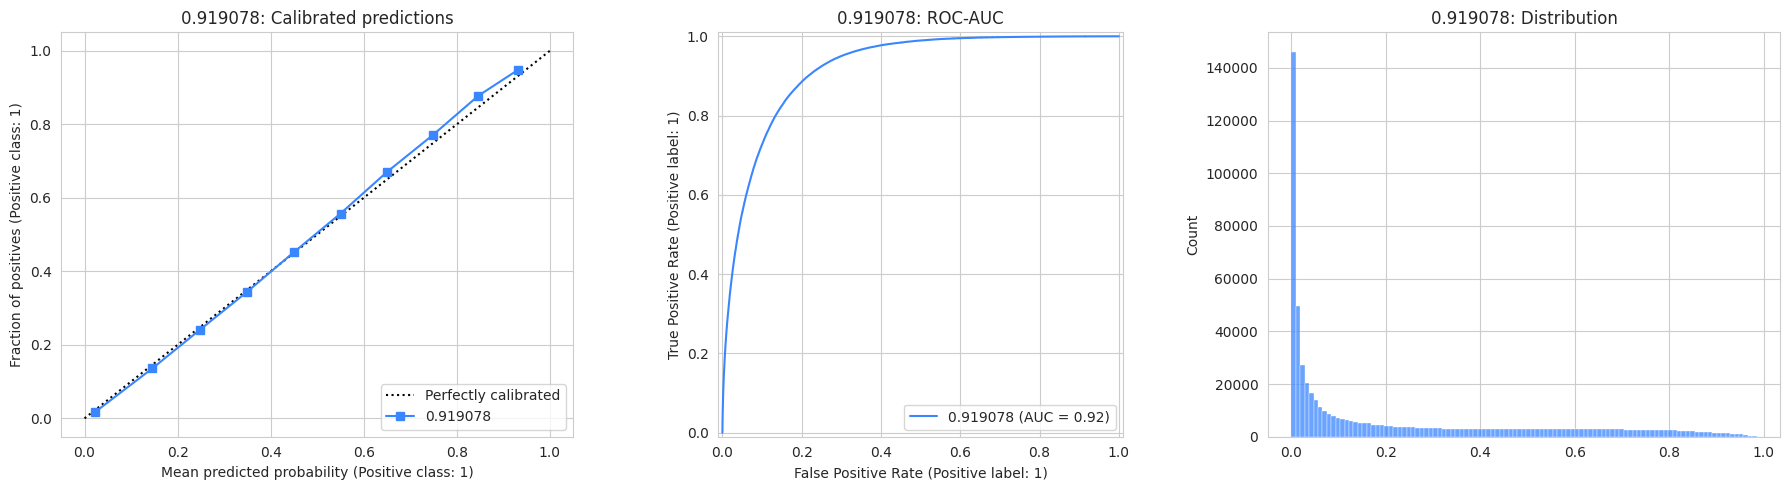


Training Time: 201.40 mins =========================


In [38]:
## -- DEFINE TRAINING PARAMETERS --
USE_FULL_TRAIN = True
train_data = train.copy() if USE_FULL_TRAIN else x_sample.reset_index(drop=True).copy()

X = train_data[FEATURES]
y = train_data[TARGET]

N_SPLITS = 10
kf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=SEED)

oof_preds  = np.zeros(len(X))
test_preds = np.zeros(len(test))
fold_scores = []
m1_scores = []

SEED_2 = 777
SEED_3 = 1234
SEED_4 = 24611
SEED_5 = 0

## -- Initiate Training --
tik = time()
for fold, (train_idx, val_idx) in enumerate(kf.split(X, y)):
    print(f"\n***** FOLD {fold+1}/{kf.n_splits}")

    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]
    X_test = test[FEATURES].copy()

    # ## -- OPTION A: Concatenate original data --
    # X_train = pd.concat([X_train, orig[FEATURES]], ignore_index=True)
    # y_train = pd.concat([y_train, orig[TARGET]], ignore_index=True)
    # y_train = np.concatenate([y_train, orig[TARGET].values], axis=0)

    TE = TargetEncoder(ALL_ROUND_BINS+INTER, cv=5, smooth='auto', aggs=['mean'], drop_original=True)
    X_train = TE.fit_transform(X_train, y_train)
    X_val   = TE.transform(X_val)
    X_test  = TE.transform(X_test)

    cme_encoder = CategoryMeanTransformer(cat_cols=['tenure'])
    X_train = cme_encoder.fit_transform(X_train, y_train).fillna(-1)
    X_val   = cme_encoder.transform(X_val).fillna(-1)
    X_test  = cme_encoder.transform(X_test).fillna(-1)

    ## -- TABM: Stage 1 model --
    model_1 = TabM_D_Classifier(**tabm_params)
    # model_1 = RealMLP_TD_Classifier(random_state=SEED)

    model_1.fit(X_train, y_train, X_val, y_val, cat_col_names=CATS+DIGITS+['cat_tenure']) 
    oof_m1 = model_1.predict_proba(X_val)[:, 1].ravel()
    test_m1 = model_1.predict_proba(X_test)[:, 1].ravel()

    score_m1 = roc_auc_score(y_val, oof_m1)
    print(f"{YELLOW} • Model_1 AUC: {score_m1:.6f}{RESET}")
    m1_scores.append(score_m1)

    ## -- PSEUDO LABELS FROM model_1 AS FEATURES FOR model_2 --
    X_train_full = pd.concat([X_train, X_val, X_test], ignore_index=True).copy()
    y_train_full = np.concatenate([y_train.to_numpy(), oof_m1, test_m1], axis=0)

    for c in CATS+DIGITS+['cat_tenure']:
        X_train_full[c] = X_train_full[c].astype(str).astype('category')

    X_val_2  = X_train_full.iloc[len(X_train):len(X_train)+len(X_val)]
    X_test_2 = X_train_full.iloc[len(X_train)+len(X_val):]

    dtrain = xgb.DMatrix(X_train_full, y_train_full, enable_categorical=True)
    dval   = xgb.DMatrix(X_val_2, y_val, enable_categorical=True)
    dtest  = xgb.DMatrix(X_test_2, enable_categorical=True)

    model_2 = xgb.train(
        xgb_params,
        dtrain,
        num_boost_round = 50_000,
        evals = [(dtrain, "train"), (dval, "valid")],
        early_stopping_rounds = 300,
        verbose_eval = 1000,
    )

    oof_preds[val_idx] = model_2.predict(dval, iteration_range=(0, model_2.best_iteration+1)).ravel()
    score_m2 = roc_auc_score(y_val, oof_preds[val_idx])
    fold_scores.append(score_m2)
    print(f"{YELLOW} • Model_2 AUC: {score_m2:.6f}{RESET}")

    if score_m2 > score_m1:
        print(f"{GREEN}❇️ PseudoLabel Improved: {score_m1:.6f} to {score_m2:.6f}{RESET}")
    else:
        print(f"{RED}🔻 PseudoLabel Dropped: {score_m1:.6f} to {score_m2:.6f}{RESET}")

    test_preds += model_2.predict(dtest, iteration_range=(0, model_2.best_iteration+1)).ravel()

    gc.collect()
    torch.cuda.empty_cache()

## -- After all folds --
test_preds /= kf.n_splits

overall_score = np.round(roc_auc_score(y, oof_preds), 6)
print(f"{'='*50}{YELLOW}")
print(f"| OOF AUC: {overall_score}") 
print(f"| AVG AUC: {np.mean(fold_scores):.6f} ± {np.std(fold_scores):.6f}")
print(f"| M_1 AUC: {np.mean(m1_scores):.6f} ± {np.std(m1_scores):.6f}")
print(f"{RESET}{'='*50}")

## -- Plot predictions errors --
_, axs = plt.subplots(1, 3, figsize=(18, 5)) 

CalibrationDisplay.from_predictions(y, oof_preds, n_bins=10, name=overall_score, ax=axs[0])
axs[0].set_title(f"{overall_score}: Calibrated predictions")

RocCurveDisplay.from_predictions(y, oof_preds, name=overall_score, ax=axs[1])
axs[1].set_title(f"{overall_score}: ROC-AUC")
# axs[1].grid(False)

sns.histplot(oof_preds, ax=axs[2])
axs[2].set_title(f"{overall_score}: Distribution")

plt.tight_layout()
plt.show()
print()

tok = time()
tiktok = (tok-tik) / 60
print(f"Training Time: {tiktok:.2f} mins {'='*25}")

In [39]:
# ==================================================
# | OOF AUC: 0.916656
# | AVG AUC: 0.916771 ± 0.000633
# | M_1 AUC: 0.916636 ± 0.000593
# ==================================================
float(overall_score)

0.919078

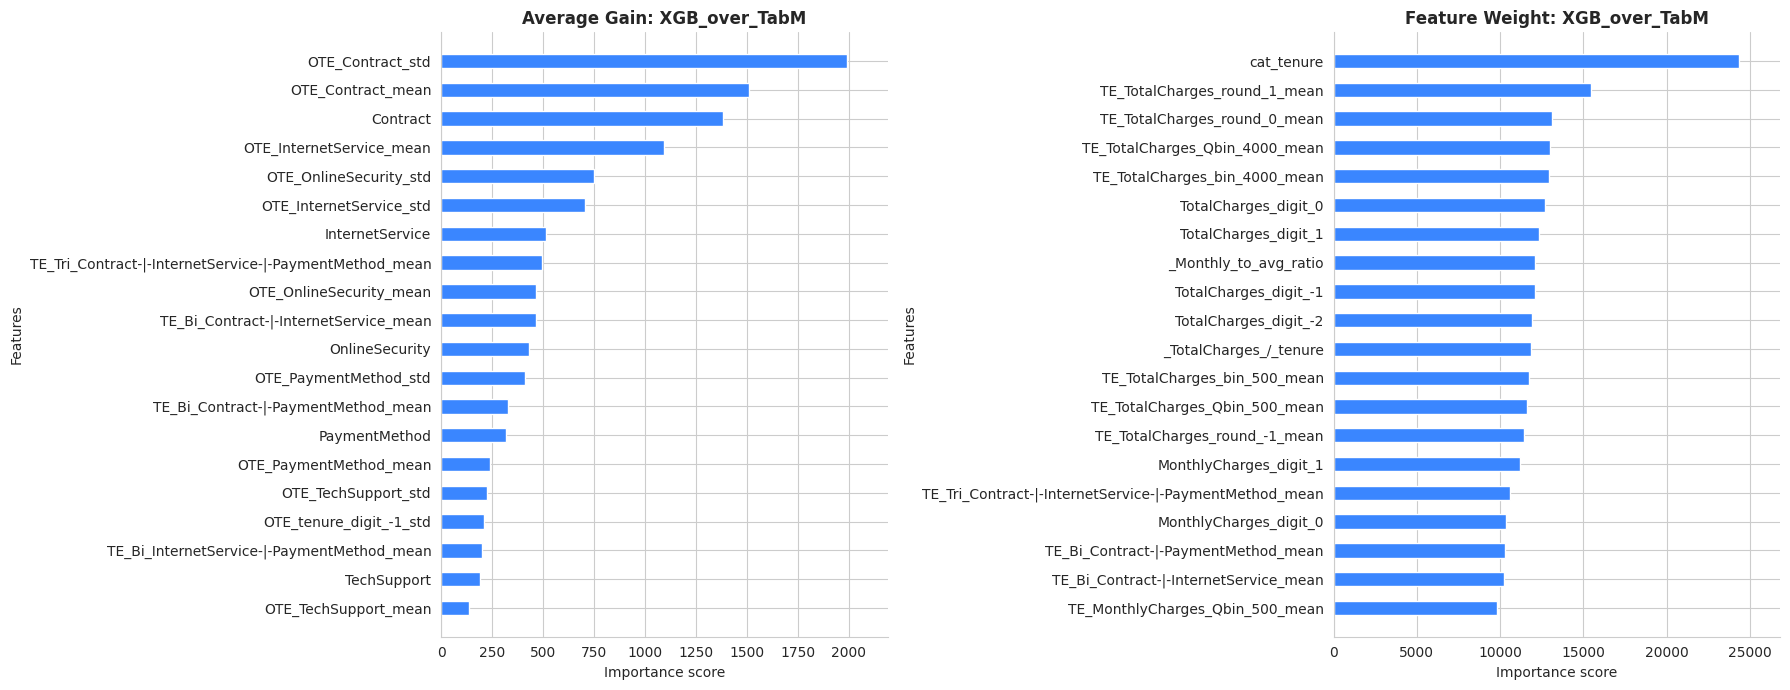

In [40]:
## -- Plot Feature Importances --
MAX = 20
_, axs = plt.subplots(1, 2, figsize=(18, 7))
xgb.plot_importance(
                    model_2, ax=axs[0],
                    max_num_features=MAX,
                    importance_type='gain',
                    height=0.5, show_values=False, #grid=False,
    )
axs[0].set_title('Average Gain: XGB_over_TabM', fontdict={'weight': 'bold'})

xgb.plot_importance(
                    model_2, ax=axs[1],
                    max_num_features=MAX,
                    importance_type='weight',
                    height=0.5, show_values=False, #grid=False,
    )
axs[1].set_title('Feature Weight: XGB_over_TabM', fontdict={'weight': 'bold'})

for ax in axs:
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

## SUBMISSION

In [41]:
## -- SAVE OOF & PREDICTIONS --
name = f"Xgb_tabM_pseudo_" + f"{overall_score}".split('.')[1]

pd.DataFrame(oof_preds, columns=[name]).to_parquet(f"oof_{name}.parquet", index=False)
pd.DataFrame(test_preds, columns=[name]).to_parquet(f"test_{name}.parquet", index=False)

## -- SUBMISSION --
submit[TARGET] = test_preds
submit.to_csv(f"submit_{name}.csv", index=False)
submit.head()

,id,Churn
0,594194,0.142147
1,594195,0.002234
2,594196,0.127976
3,594197,0.008085
4,594198,0.538830
